# Shot Zone Efficiency

This section examines how field goal percentage has changed across NBA seasons, highlighting trends in different zones and offensive strategy over time.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Loading in Datasets

seasons = [
    "2013-14","2014-15","2015-16","2016-17",
    "2017-18","2018-19","2019-20","2020-21",
    "2021-22","2022-23","2023-24","2024-25",
    "2025-26"
]

dfs = []

for season in seasons:
    temp = pd.read_parquet(
        f"data/raw/shots/shots_{season}.parquet"
    )
    dfs.append(temp)

shots = pd.concat(dfs, ignore_index=True)

# FG% By Shot Zones

In [5]:
zone_fg = (
    shots.groupby("SHOT_ZONE_BASIC")["SHOT_MADE_FLAG"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

zone_fg

SHOT_ZONE_BASIC
Restricted Area          63.566989
In The Paint (Non-RA)    42.061104
Mid-Range                40.465701
Right Corner 3           38.664006
Left Corner 3            38.591410
Above the Break 3        35.179625
Backcourt                 2.752925
Name: SHOT_MADE_FLAG, dtype: float64

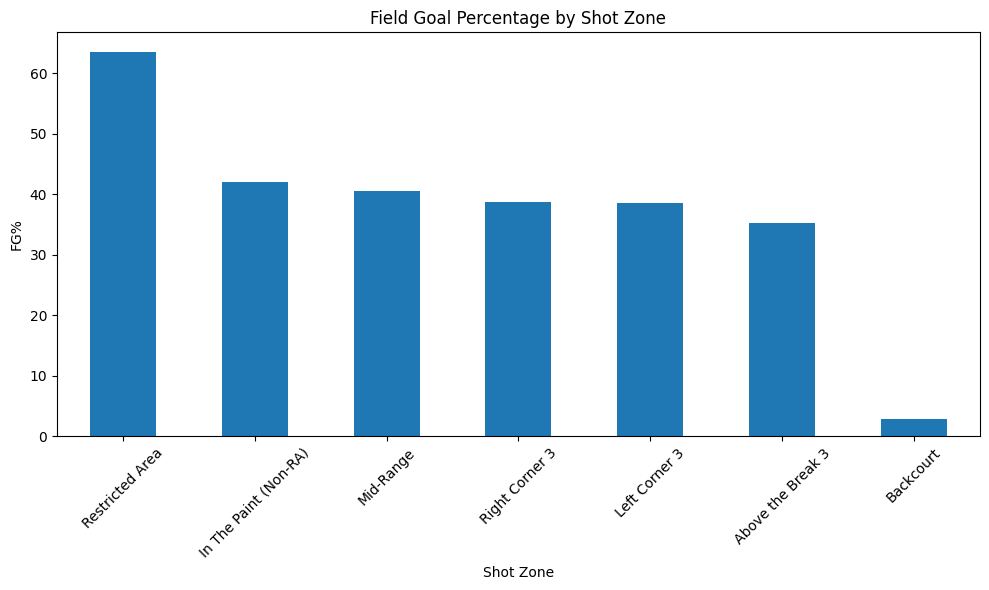

In [6]:
plt.figure(figsize=(10,6))

zone_fg.plot(kind="bar")

plt.title("Field Goal Percentage by Shot Zone")
plt.xlabel("Shot Zone")
plt.ylabel("FG%")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Shot Efficiency Per Season

In [7]:
zone_efficiency = []

for season in seasons:
    temp = pd.read_parquet(f"data/raw/shots/shots_{season}.parquet")

    fg_pct = (temp.groupby("SHOT_ZONE_BASIC")["SHOT_MADE_FLAG"].mean().mul(100))

    for zone, pct in fg_pct.items():
        zone_efficiency.append({"Season": season, "Zone": zone, "FG_PCT": pct})

zone_efficiency = pd.DataFrame(zone_efficiency)

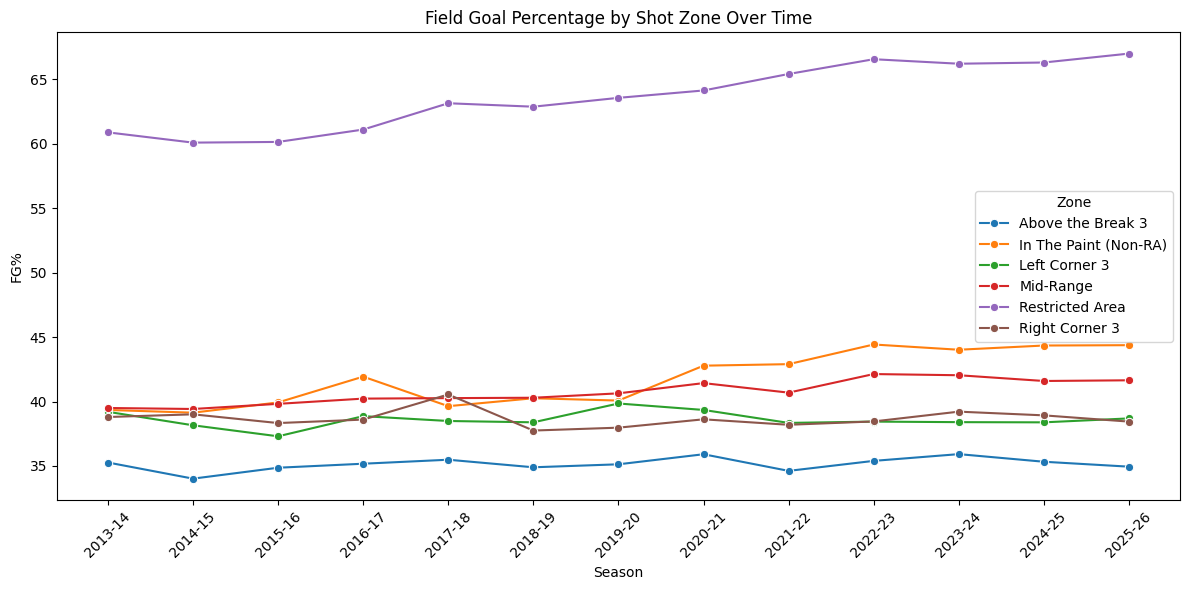

In [9]:
zone_efficiency = zone_efficiency[
    zone_efficiency["Zone"] != "Backcourt"
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=zone_efficiency,
    x="Season",
    y="FG_PCT",
    hue="Zone",
    marker="o"
)

plt.title("Field Goal Percentage by Shot Zone Over Time")
plt.ylabel("FG%")
plt.xlabel("Season")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Change in FG Percentage and Attempts from 2013-2026

In [16]:
zone_summary = []

for season in seasons:
    temp = pd.read_parquet(f"data/raw/shots/shots_{season}.parquet")
    temp = temp[temp["SHOT_ZONE_BASIC"] != "Backcourt"]

    grouped = temp.groupby("SHOT_ZONE_BASIC").agg(
        Attempts=("SHOT_MADE_FLAG", "count"),
        FG_PCT=("SHOT_MADE_FLAG", "mean")
    )

    grouped["FG_PCT"] = grouped["FG_PCT"] * 100
    grouped["Attempt_PCT"] = grouped["Attempts"] / len(temp) * 100
    grouped["Season"] = season

    zone_summary.append(grouped.reset_index())

zone_summary = pd.concat(zone_summary, ignore_index=True)

In [15]:
start = zone_summary[zone_summary["Season"] == "2013-14"].set_index("SHOT_ZONE_BASIC")
end = zone_summary[zone_summary["Season"] == "2025-26"].set_index("SHOT_ZONE_BASIC")

zone_change = pd.DataFrame({
    "2013-14 Attempts": start["Attempts"],
    "2025-26 Attempts": end["Attempts"],
    "Attempt Change": end["Attempts"] - start["Attempts"],
    "2013-14 Attempt %": start["Attempt_PCT"],
    "2025-26 Attempt %": end["Attempt_PCT"],
    "Attempt % Change": end["Attempt_PCT"] - start["Attempt_PCT"],
    "2013-14 FG%": start["FG_PCT"],
    "2025-26 FG%": end["FG_PCT"],
    "FG% Change": end["FG_PCT"] - start["FG_PCT"]
})

zone_change.sort_values("Attempt % Change", ascending=False)

,2013-14 Attempts,2025-26 Attempts,Attempt Change,2013-14 Attempt %,2025-26 Attempt %,Attempt % Change,2013-14 FG%,2025-26 FG%,FG% Change
SHOT_ZONE_BASIC,,,,,,,,,
Above the Break 3,41885,71289,29404,19.219562,30.676845,11.457283,35.270383,34.947888,-0.322495
In The Paint (Non-RA),32539,46547,14008,14.931010,20.029950,5.098940,39.346630,44.370206,5.023576
Right Corner 3,6861,12049,5188,3.148273,5.184886,2.036612,38.799009,38.443024,-0.355985
Left Corner 3,7686,12923,5237,3.526837,5.560982,2.034146,39.201145,38.690706,-0.510438
Restricted Area,70404,66019,-4385,32.305935,28.409076,-3.896858,60.875803,66.986777,6.110974
Mid-Range,58505,23560,-34945,26.845899,10.138261,-16.707639,39.499188,41.646859,2.147671


# Sample of 10000 Shots, 2013 compared to 2026

In [18]:
shots_2013 = pd.read_parquet("data/raw/shots/shots_2013-14.parquet")
shots_2026 = pd.read_parquet("data/raw/shots/shots_2025-26.parquet")

sample_2013 = shots_2013.sample(10000, random_state=42)
sample_2026 = shots_2026.sample(10000, random_state=42)

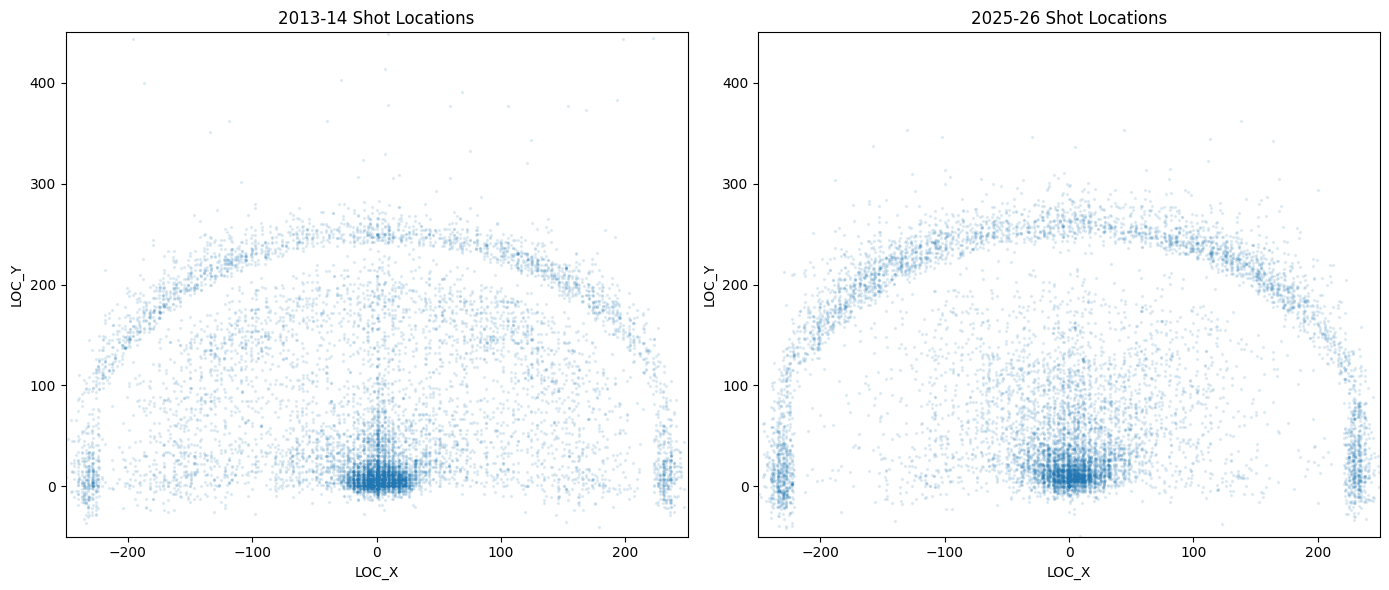

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(sample_2013["LOC_X"], sample_2013["LOC_Y"], alpha=0.1, s=2)
axes[0].set_title("2013-14 Shot Locations")

axes[1].scatter(sample_2026["LOC_X"], sample_2026["LOC_Y"], alpha=0.1, s=2)
axes[1].set_title("2025-26 Shot Locations")

# 
for ax in axes: 
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 450)
    ax.set_xlabel("LOC_X")
    ax.set_ylabel("LOC_Y")

plt.tight_layout()
plt.show()